# FDM Project — Phase 1: Understand Data

## Task 2 — Individual EDA

### Collision Dataset Exploratory Data Analysis

### Objective

The purpose of this analysis is to independently explore the raw
Collision dataset before integration with the Vehicle and Casualty
datasets.

The EDA focuses on:

- Data distributions
- Categorical frequencies
- Missing values
- Sentinel and unknown codes
- Outliers and extreme values
- Date and time coverage
- Geographic ranges
- Target-variable behaviour
- Potential data-quality issues

No data cleaning, joining, aggregation, or feature engineering is
performed during this EDA.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [2]:
collision_df = pd.read_csv(
    "../data/dft-road-casualty-statistics-collision-last-5-years.csv"
)

print("Collision dataset loaded successfully.")

Collision dataset loaded successfully.


C:\Users\IMAKA\AppData\Local\Temp\ipykernel_11596\1375343471.py:1: DtypeWarning: Columns (0: collision_index, 2: collision_ref_no) have mixed types. Specify dtype option on import or set low_memory=False.
  collision_df = pd.read_csv(


In [3]:
print("Rows    :", collision_df.shape[0])
print("Columns :", collision_df.shape[1])

Rows    : 513801
Columns : 44


In [4]:
collision_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 513801 entries, 0 to 513800
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   513801 non-null  object 
 1   collision_year                                    513801 non-null  int64  
 2   collision_ref_no                                  513801 non-null  object 
 3   location_easting_osgr                             513748 non-null  float64
 4   location_northing_osgr                            513748 non-null  float64
 5   longitude                                         513748 non-null  float64
 6   latitude                                          513748 non-null  float64
 7   police_force                                      513801 non-null  int64  
 8   collision_severity                                513801 non-null  int64  
 9   number_of_vehic

In [5]:
display(collision_df.head(10))

,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202517M102225,2025,17M102225,449804.0,519612.0,-1.23119,54.56929,17,3,1,...,-1,0,1,1,2,E01012092,3,1,0.0,1.0
1,202417S111924,2024,17S111924,444670.0,520502.0,-1.31046,54.57776,17,2,1,...,-1,0,1,1,2,E01012194,7,1,1.0,0.0
2,2025111687011,2025,111687011,427772.0,515144.0,-1.57237,54.53082,11,3,2,...,-1,0,1,3,2,E01035185,3,1,0.0,1.0
3,2025070326701,2025,070326701,351585.0,382993.0,-2.72862,53.34161,7,1,1,...,-1,0,1,1,2,E01012430,1,1,0.0,0.0
4,2025070353559,2025,070353559,351101.0,382954.0,-2.73589,53.34121,7,3,2,...,-1,0,1,2,2,E01012431,3,1,0.0,1.0
5,2025070516824,2025,070516824,361983.0,389761.0,-2.57328,53.40329,7,3,2,...,-1,0,1,3,2,E01012524,3,1,0.0,1.0
6,2025070962415,2025,070962415,361512.0,386901.0,-2.58001,53.37755,7,2,1,...,-1,0,1,1,2,E01012510,7,1,1.0,0.0
7,2025071027741,2025,071027741,362451.0,390421.0,-2.56632,53.40926,7,3,1,...,-1,0,1,3,2,E01012546,3,1,0.0,1.0
8,2024041412028,2024,041412028,369385.0,427453.0,-2.46566,53.74255,4,3,1,...,-1,0,1,2,2,E01012630,3,1,0.0,1.0
9,2024041446374,2024,041446374,367151.0,427575.0,-2.49954,53.74351,4,3,2,...,-1,0,1,1,2,E01012655,3,1,0.0,1.0


## Numerical Descriptive Statistics

Descriptive statistics are calculated for numerical fields to
understand their distributions, central tendency, variability,
and extreme values.

The results are used to identify variables that may require
further investigation.

In [6]:
collision_df.describe().T

,count,mean,std,min,25%,50%,75%,max
collision_year,513801.0,2022.991824,1.407139,2021.000000,2022.000000,2023.000000,2024.000000,2.025000e+03
location_easting_osgr,513748.0,454945.487375,92658.538917,67564.000000,392630.000000,460443.500000,529549.250000,6.553450e+05
location_northing_osgr,513748.0,275427.620133,145647.350208,10211.000000,175147.000000,217372.500000,382395.000000,1.179892e+06
longitude,513748.0,-1.211037,1.355154,-7.486852,-2.111008,-1.106897,-0.133341,1.759829e+00
latitude,513748.0,52.366318,1.312262,49.912210,51.462346,51.843188,53.334331,6.050001e+01
police_force,513801.0,27.605160,24.207953,1.000000,5.000000,22.000000,45.000000,9.900000e+01
collision_severity,513801.0,2.743249,0.469288,1.000000,3.000000,3.000000,3.000000,3.000000e+00
number_of_vehicles,513801.0,1.824179,0.687802,1.000000,1.000000,2.000000,2.000000,2.600000e+01
number_of_casualties,513801.0,1.270572,0.726348,1.000000,1.000000,1.000000,1.000000,1.420000e+02
day_of_week,513801.0,4.137765,1.934211,1.000000,2.000000,4.000000,6.000000,7.000000e+00


## Suspicious Findings from Numerical Summary

1. `number_of_vehicles` has an unusually high maximum of 26 compared with
   a median of 2. This extreme observation requires investigation.

2. `number_of_casualties` has a maximum of 142 while the median and 75th
   percentile are both 1. This indicates a highly skewed distribution and
   requires investigation of extreme observations.

3. The four geographic variables contain 53 missing observations each.
   According to the DfT Data Guide, null values indicate that the location
   is not known.

4. `local_authority_district` contains a large number of -1 values.
   According to the DfT Data Guide, -1 means "Code deprecated" for this
   variable.

5. `speed_limit` contains -1 values. The DfT Data Guide defines -1 as
   "Data missing or out of range", while valid public-highway speed limits
   are 20, 30, 40, 50, 60 and 70.

6. `first_road_number` and `second_road_number` contain -1 and 0 values.
   These values are not automatically errors because the DfT Data Guide
   defines their meanings explicitly.

7. Several coded categorical variables contain -1 values. Their meanings
   must be interpreted according to the official DfT definition for each
   variable rather than treating -1 as an ordinary numerical value.

8. Severity-related variables require further investigation because
   `collision_severity` is the primary target of the project.

In [7]:
collision_df["collision_severity"].value_counts()

collision_severity
3    389435
2    116813
1      7553
Name: count, dtype: int64

## Categorical Variable Frequencies

Frequency distributions are calculated for categorical and coded
categorical variables.

This helps identify dominant categories, rare categories, and
potential unknown or sentinel codes.

In [8]:
categorical_columns = [
    "collision_severity",
    "day_of_week",
    "police_force",
    "first_road_class",
    "road_type",
    "speed_limit",
    "junction_detail",
    "junction_control",
    "second_road_class",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "special_conditions_at_site",
    "carriageway_hazards",
    "urban_or_rural_area",
    "did_police_officer_attend_scene_of_accident",
    "trunk_road_flag"
]

for column in categorical_columns:
    print(f"\n{'=' * 70}")
    print(column)
    print("=" * 70)
    display(collision_df[column].value_counts(dropna=False))


collision_severity


collision_severity
3    389435
2    116813
1      7553
Name: count, dtype: int64


day_of_week


day_of_week
6    85311
5    77954
4    76671
3    74829
2    70677
7    70578
1    57781
Name: count, dtype: int64


police_force


...

urban_or_rural_area
 1    345314
 2    168429
 3        50
-1         8
Name: count, dtype: int64


did_police_officer_attend_scene_of_accident


did_police_officer_attend_scene_of_accident
1    355712
3     98073
2     60016
Name: count, dtype: int64


trunk_road_flag


trunk_road_flag
 2    444654
-1     36318
 1     32829
Name: count, dtype: int64

## Suspicious / Important Findings from Collision EDA

The following observations were identified during the exploratory data analysis of the Collision dataset. These findings **do not mean the data is incorrect**; they indicate values or distributions that require further investigation during the data-quality and preprocessing stages.

### 1. Strong Class Imbalance in `collision_severity`
- **Slight:** 389,435 (75.81%)
- **Serious:** 116,813 (22.73%)
- **Fatal:** 7,553 (1.47%)
- The target variable is highly imbalanced, particularly for the **Fatal** class.
- This should be considered during model training and evaluation.

### 2. High Missing/Out-of-Range Values in `junction_control`
- `-1`: **217,897 records (42.41%)**
- A large proportion of the dataset contains the `-1` code.
- This requires investigation using the official DfT data definitions before deciding how it should be handled.

### 3. High Missing/Out-of-Range Values in `special_conditions_at_site`
- `-1`: **151,370 records (29.46%)**
- Almost one-third of the collision records contain this code.
- This is a significant data-quality issue that requires further investigation.

### 4. Missing/Out-of-Range Values in `trunk_road_flag`
- `-1`: **36,318 records (7.07%)**
- A noticeable proportion of records have missing/out-of-range values.
- This should be investigated before preprocessing.

### 5. Missing/Unknown Values in `junction_detail`
- `-1`: **19,982 records**
- `99`: **1,429 records**
- Combined: **21,411 records (4.17%)**
- These values should be investigated using the DfT code definitions.

### 6. Missing/Unknown Values in `carriageway_hazards`
- `-1`: **9,891 records**
- `99`: **9,172 records**
- Combined: **19,063 records (3.71%)**
- These values require investigation before deciding how to treat them.

### 7. Unknown Values in `weather_conditions`
- `9`: **14,566 records (2.83%)**
- This represents a noticeable number of unknown weather-condition records.
- The impact of these values should be considered during preprocessing.

### 8. Unknown Values in `road_type`
- `9`: **13,060 records (2.54%)**
- A noticeable proportion of records have an unknown road type.
- This should be investigated before feature encoding.

### 9. Missing/Out-of-Range Values in `second_road_class`
- `-1`: **11,566 records (2.25%)**
- `9`: **48 records**
- These values should be reviewed according to the DfT coding definitions.

### 10. Missing/Unknown Values in `road_surface_conditions`
- `-1`: **3,527 records (0.69%)**
- `9`: **6,721 records (1.31%)**
- Combined: **10,248 records (~2.00%)**
- These values should be investigated during data-quality validation.

### 11. Extreme Value in `number_of_vehicles`
- Median: **2 vehicles**
- Maximum: **26 vehicles**
- The maximum is considerably higher than the typical collision.
- It is not necessarily an error, but the extreme records should be investigated.

### 12. Extreme Value in `number_of_casualties`
- Median: **1 casualty**
- Q1: **1**
- Q3: **1**
- Maximum: **142 casualties**
- The maximum is extremely high compared with the typical collision.
- It should be investigated as a potential extreme observation rather than automatically removed.

### 13. Missing Geographic Coordinates
The following geographic fields each contain **53 missing values**:

- `location_easting_osgr`
- `location_northing_osgr`
- `longitude`
- `latitude`

These records should be investigated before performing geographic analysis or hotspot clustering.

---

## Summary of Main Suspicious Findings

| Variable | Issue | Approx. Proportion | Priority |
|---|---|---:|---|
| `collision_severity` | Strong class imbalance | Fatal = 1.47% | High |
| `junction_control` | `-1` values | 42.41% | High |
| `special_conditions_at_site` | `-1` values | 29.46% | High |
| `trunk_road_flag` | `-1` values | 7.07% | Medium |
| `junction_detail` | `-1` / `99` | 4.17% | Medium |
| `carriageway_hazards` | `-1` / `99` | 3.71% | Medium |
| `weather_conditions` | Unknown `9` | 2.83% | Medium |
| `road_type` | Unknown `9` | 2.54% | Medium |
| `second_road_class` | `-1` / `9` | 2.25% | Medium |
| `road_surface_conditions` | `-1` / `9` | ~2.00% | Medium |
| `number_of_casualties` | Maximum = 142 | Extreme value | Investigate |
| `number_of_vehicles` | Maximum = 26 | Extreme value | Investigate |
| Geographic coordinates | 53 missing values | Very low | Low |

> **Important:** These findings are identified during EDA only. No values should be removed, replaced, or transformed at this stage. The appropriate treatment should be decided later during the **data-quality validation and preprocessing stages**, using the official DfT definitions and project requirements.

## 7. Categorical Frequencies and Percentages

Percentages are calculated alongside frequencies to understand the
relative distribution of categories regardless of the total number
of observations.

This helps identify dominant categories, rare categories, and
potential unknown or sentinel codes.

In [9]:
for column in categorical_columns:
    print(f"\n{column}")
    
    frequency = collision_df[column].value_counts(dropna=False)
    
    percentage = (
        collision_df[column]
        .value_counts(normalize=True, dropna=False) * 100
    )
    
    summary = pd.DataFrame({
        "Count": frequency,
        "Percentage": percentage.round(2)
    })
    
    display(summary)


collision_severity


,Count,Percentage
collision_severity,,
3,389435,75.79
2,116813,22.74
1,7553,1.47



day_of_week


,Count,Percentage
day_of_week,,
6,85311,16.60
5,77954,15.17
4,76671,14.92
3,74829,14.56
2,70677,13.76
7,70578,13.74
1,57781,11.25



police_force


...

,Count,Percentage
urban_or_rural_area,,
1,345314,67.21
2,168429,32.78
3,50,0.01
-1,8,0.00



did_police_officer_attend_scene_of_accident


,Count,Percentage
did_police_officer_attend_scene_of_accident,,
1,355712,69.23
3,98073,19.09
2,60016,11.68



trunk_road_flag


,Count,Percentage
trunk_road_flag,,
2,444654,86.54
-1,36318,7.07
1,32829,6.39


## Categorical Frequency Findings — Issues Requiring Investigation

The categorical frequency analysis identified several distributions
and coded values that require further investigation during the data
quality and preprocessing stages.

### 1. Class Imbalance in `collision_severity`

The collision severity distribution is highly imbalanced:

- Slight: 75.79%
- Serious: 22.74%
- Fatal: 1.47%

The Fatal class represents a relatively small proportion of the
dataset. This is important for the later classification stage because
model evaluation should consider class-specific performance rather
than relying only on overall accuracy.

### 2. High Proportion of `-1` in `junction_control`

The `junction_control` variable contains:

- `-1`: 42.41%

This is a substantial proportion of the dataset and requires
investigation using the official DfT code definitions before deciding
how it should be handled.

### 3. High Proportion of `-1` in `special_conditions_at_site`

The `special_conditions_at_site` variable contains:

- `-1`: 29.46%

This is a relatively large proportion of records and should be
investigated during the data-quality stage.

### 4. Missing/Unknown Codes in `trunk_road_flag`

The `trunk_road_flag` variable contains:

- `-1`: 7.07%

This represents a noticeable proportion of the dataset and should
be investigated before preprocessing.

### 5. Missing/Unknown Codes in `junction_detail`

The `junction_detail` variable contains:

- `-1`: 3.89%
- `99`: 0.28%

Together, these account for approximately 4.17% of the records and
require investigation.

### 6. Unknown Codes in `weather_conditions`

The `weather_conditions` variable contains:

- `9`: 2.83%

This is a noticeable proportion of records represented by an unknown
category and should be investigated.

### 7. Unknown Codes in `road_type`

The `road_type` variable contains:

- `9`: 2.54%

This should be reviewed using the official DfT coding definitions
before deciding how it will be treated.

### 8. Missing/Unknown Codes in `second_road_class`

The `second_road_class` variable contains:

- `-1`: 2.25%
- `9`: 0.01%

These coded values should be investigated during the data-quality
stage.

### 9. Missing/Unknown Codes in `road_surface_conditions`

The `road_surface_conditions` variable contains:

- `-1`: 0.69%
- `9`: 1.31%

Together, these account for approximately 2.00% of the records and
should be investigated.

### 10. Missing/Unknown Codes in `carriageway_hazards`

The `carriageway_hazards` variable contains:

- `-1`: 1.93%
- `99`: 1.79%

Together, these account for approximately 3.72% of the records and
require further investigation.

### 11. Rare Categories

Some categories occur very rarely, including:

- `urban_or_rural_area = 3`: 0.01%
- `first_road_class = -1`: approximately 0.00%
- `speed_limit = -1`: approximately 0.00%
- `light_conditions = -1`: 0.01%
- `second_road_class = 2`: 0.05%

These are not automatically errors. Their meanings and appropriate
treatment should be determined from the official DfT definitions
during the data-quality stage.

### Overall Finding

The main categorical data-quality concerns identified at this stage
are the high proportions of coded `-1` values in `junction_control`
and `special_conditions_at_site`, followed by the noticeable coded
unknown/missing values in `trunk_road_flag`, `junction_detail`,
`carriageway_hazards`, `weather_conditions`, `road_type`,
`second_road_class`, and `road_surface_conditions`.

These findings are recorded for further investigation. No values are
removed, replaced, or recoded during this EDA stage.

## 8. Missing-Value Analysis

Missing values are profiled for every column in the Collision
dataset.

Both the number and percentage of missing observations are
calculated so that fields with substantial missingness can be
identified for later investigation.

No missing values are filled or removed during this EDA stage.

In [10]:
missing_summary = pd.DataFrame({
    "Missing Count": collision_df.isna().sum(),
    "Missing Percentage": (
        collision_df.isna().sum() / len(collision_df) * 100
    )
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
location_easting_osgr,53,0.010315
latitude,53,0.010315
longitude,53,0.010315
location_northing_osgr,53,0.010315
collision_ref_no,0,0.000000
collision_year,0,0.000000
collision_index,0,0.000000
police_force,0,0.000000
collision_severity,0,0.000000
number_of_vehicles,0,0.000000


In [11]:
missing_only = missing_summary[
    missing_summary["Missing Count"] > 0
]

display(missing_only)

,Missing Count,Missing Percentage
location_easting_osgr,53,0.010315
latitude,53,0.010315
longitude,53,0.010315
location_northing_osgr,53,0.010315


## Missing-Value Findings — Collision Dataset

The missing-value analysis shows that actual missing (`NaN`) values are
very limited in the Collision dataset.

Four geographic variables contain missing values:

- `location_easting_osgr`: 53 records (0.0103%)
- `location_northing_osgr`: 53 records (0.0103%)
- `latitude`: 53 records (0.0103%)
- `longitude`: 53 records (0.0103%)

All other Collision variables contain no actual missing (`NaN`) values.

The missing values are therefore concentrated in the geographic
location fields and represent a very small proportion of the dataset.

It should also be noted that coded values such as `-1` and `99` are
not counted as `NaN` missing values. These coded values were identified
separately during the categorical frequency analysis and require
investigation according to the official DfT definitions.

No missing values are filled or removed during the EDA stage.

## 9. Date and Time Coverage

The temporal fields are examined to determine the period covered
by the dataset and to identify missing or unusual date/time values.

No temporal features are created at this stage.

In [12]:
print("Collision years:")
display(
    collision_df["collision_year"]
    .value_counts()
    .sort_index()
)

Collision years:


collision_year
2021    101087
2022    106004
2023    104258
2024    100927
2025    101525
Name: count, dtype: int64

In [13]:
print("Day of week:")
display(
    collision_df["day_of_week"]
    .value_counts()
    .sort_index()
)

Day of week:


day_of_week
1    57781
2    70677
3    74829
4    76671
5    77954
6    85311
7    70578
Name: count, dtype: int64

In [14]:
print("Date range:")
print("Minimum:", collision_df["date"].min())
print("Maximum:", collision_df["date"].max())

Date range:
Minimum: 01/01/2021
Maximum: 31/12/2025


In [15]:
print("Sample time values:")
display(collision_df["time"].head(20))

Sample time values:


0     19:15
1     14:48
2     06:40
3     20:03
4     17:40
5     09:18
6     16:40
7     17:00
8     17:25
9     20:33
10    15:43
11    08:35
12    08:20
13    16:30
14    15:30
15    12:50
16    07:35
17    23:40
18    11:08
19    08:20
Name: time, dtype: str

## Temporal Findings — Collision Dataset

The temporal analysis shows that the Collision dataset covers the
expected five-year period from 2021 to 2025.

The number of collision records is distributed across all five years:

- 2021: 101,087
- 2022: 106,004
- 2023: 104,258
- 2024: 100,927
- 2025: 101,525

No year is missing, and there is no obvious abnormal gap in the
yearly coverage.

All seven day-of-week categories are present. Friday has the highest
number of recorded collisions, while Sunday has the lowest. These
differences represent the observed distribution of collisions and do
not by themselves indicate a data-quality problem.

The date range extends from `01/01/2021` to `31/12/2025`, which is
consistent with the intended five-year coverage.

The sampled `time` values follow an `HH:MM` format, with examples such
as `19:15`, `14:48`, and `06:40`. No obvious formatting issue was
identified from the inspected values.

Overall, no major suspicious temporal issue was identified from this
initial analysis.

## 10. Geographic Range Analysis

The geographic variables are examined to understand their value
ranges, identify potentially unusual coordinate values, and assess
the availability of location information.

No geographic values are modified or removed during this EDA stage.

In [16]:
geo_columns = [
    "latitude",
    "longitude",
    "location_easting_osgr",
    "location_northing_osgr"
]

collision_df[geo_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,513748.0,52.366318,1.312262,49.912210,51.462346,51.843188,53.334331,6.050001e+01
longitude,513748.0,-1.211037,1.355154,-7.486852,-2.111008,-1.106897,-0.133341,1.759829e+00
location_easting_osgr,513748.0,454945.487375,92658.538917,67564.000000,392630.000000,460443.500000,529549.250000,6.553450e+05
location_northing_osgr,513748.0,275427.620133,145647.350208,10211.000000,175147.000000,217372.500000,382395.000000,1.179892e+06


In [17]:
display(
    collision_df[geo_columns]
    .isna()
    .sum()
    .to_frame("Missing Count")
)

,Missing Count
latitude,53
longitude,53
location_easting_osgr,53
location_northing_osgr,53


## Geographic Findings — Collision Dataset

The geographic variables show the observed spatial ranges of the
collision records.

- `latitude` ranges from 49.912210 to 60.500010.
- `longitude` ranges from -7.486852 to 1.759829.
- `location_easting_osgr` ranges from 67,564 to 655,345.
- `location_northing_osgr` ranges from 10,211 to 1,179,892.

All four geographic variables contain 53 missing values, representing
approximately 0.01% of the dataset.

The observed coordinate ranges do not show an obvious extreme value
requiring immediate treatment based on this initial EDA.

The 53 missing geographic records should be recorded for later
investigation, particularly because geographic information will be
relevant to the project's spatial analysis and hotspot identification.

No geographic values are modified or removed during this EDA stage.

## 11. Outlier and Extreme-Value Investigation

Numerical variables are examined for unusually low or high values.

An extreme value is not automatically considered incorrect. Values
identified as unusual are recorded for further investigation and may
be addressed later during the data-quality and preprocessing stages.

No outliers are removed or modified during this EDA stage.

In [18]:
numerical_columns = [
    "number_of_vehicles",
    "number_of_casualties",
    "speed_limit",
    "latitude",
    "longitude",
    "location_easting_osgr",
    "location_northing_osgr"
]

collision_df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
number_of_vehicles,513801.0,1.824179,0.687802,1.000000,1.000000,2.000000,2.000000,2.600000e+01
number_of_casualties,513801.0,1.270572,0.726348,1.000000,1.000000,1.000000,1.000000,1.420000e+02
speed_limit,513801.0,35.899516,14.371273,-1.000000,30.000000,30.000000,40.000000,7.000000e+01
latitude,513748.0,52.366318,1.312262,49.912210,51.462346,51.843188,53.334331,6.050001e+01
longitude,513748.0,-1.211037,1.355154,-7.486852,-2.111008,-1.106897,-0.133341,1.759829e+00
location_easting_osgr,513748.0,454945.487375,92658.538917,67564.000000,392630.000000,460443.500000,529549.250000,6.553450e+05
location_northing_osgr,513748.0,275427.620133,145647.350208,10211.000000,175147.000000,217372.500000,382395.000000,1.179892e+06


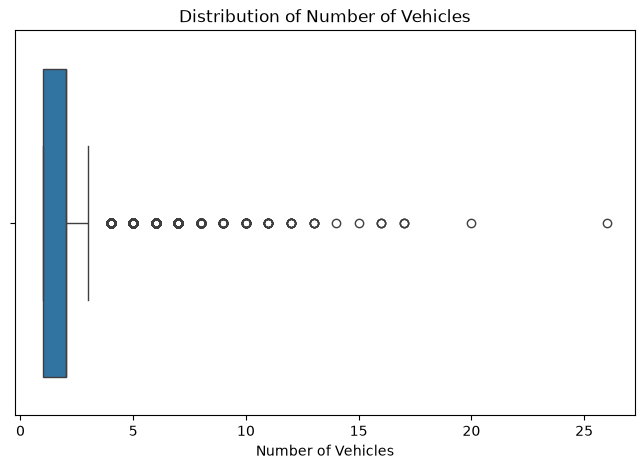

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=collision_df["number_of_vehicles"]
)

plt.title("Distribution of Number of Vehicles")
plt.xlabel("Number of Vehicles")

plt.show()

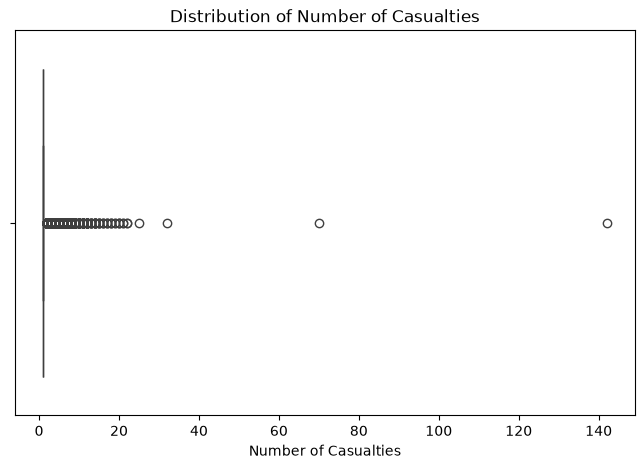

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=collision_df["number_of_casualties"]
)

plt.title("Distribution of Number of Casualties")
plt.xlabel("Number of Casualties")

plt.show()

In [21]:
print("Highest number of vehicles:")
display(
    collision_df[
        ["collision_index", "number_of_vehicles", "number_of_casualties"]
    ]
    .sort_values("number_of_vehicles", ascending=False)
    .head(10)
)

Highest number of vehicles:


,collision_index,number_of_vehicles,number_of_casualties
11142,2024471416027,26,21
99549,2024461393694,20,1
104196,2025010580108,17,1
386736,2023991290248,17,7
202368,2023010481010,17,3
255549,2024543395024,16,6
230037,2022440051672,16,1
235980,2022371220504,16,1
159906,2023991314378,15,3
212813,2023031260958,14,1


In [22]:
print("Highest number of casualties:")
display(
    collision_df[
        ["collision_index", "number_of_vehicles", "number_of_casualties"]
    ]
    .sort_values("number_of_casualties", ascending=False)
    .head(10)
)

Highest number of casualties:


,collision_index,number_of_vehicles,number_of_casualties
276946,2025052501204,1,142
215172,2023520300610,3,70
111363,2025041681268,1,32
122194,2025520501079,1,25
13353,2025351616661,3,22
186782,202163CF00721,2,22
76318,2024461446505,2,21
11142,2024471416027,26,21
94481,2025340NN2152,2,20
19042,2024141499595,2,20


## Outlier and Extreme-Value Findings — Collision Dataset

The outlier analysis identified strong right-skewness and several
extreme observations in the collision-level numerical variables.

### 1. Extreme Values in `number_of_vehicles`

The typical collision involves a small number of vehicles:

- Median: 2 vehicles
- Q1: 1 vehicle
- Q3: 2 vehicles
- Maximum: 26 vehicles

The boxplot shows several observations above the typical range.
The highest observed collision contains 26 vehicles and 21 casualties.

These observations are considered extreme and require further
investigation, but they are not automatically treated as errors.

### 2. Extreme Values in `number_of_casualties`

The `number_of_casualties` variable is strongly right-skewed:

- Median: 1 casualty
- Q1: 1 casualty
- Q3: 1 casualty
- Maximum: 142 casualties

Several observations have substantially higher casualty counts than
the typical collision.

The highest observed record contains 142 casualties with 1 vehicle,
while another record contains 70 casualties with 3 vehicles. These
records require further validation, particularly against the linked
Casualty dataset.

### 3. Coded Value in `speed_limit`

The minimum value of `speed_limit` is `-1`. Only 3 records contain
this value.

This value should not be interpreted as a normal numerical speed
limit and should be investigated using the official DfT coding
definition during the data-quality stage.

### Overall Finding

The main extreme-value concerns in the Collision dataset are the
very high values of `number_of_vehicles` and `number_of_casualties`.

These observations are flagged for investigation rather than
automatically removed or modified. Further validation will be
performed during the data-quality and dataset-integration stages.

## 12. Collision Severity Distribution

`collision_severity` is the primary classification target of the project.

Its frequency and percentage distribution are examined to understand
the distribution of Fatal, Serious, and Slight collisions and to identify
any class imbalance.

This is descriptive analysis only. No class-balancing technique or
target transformation is applied during EDA.

In [23]:
severity_summary = pd.DataFrame({
    "Count": collision_df["collision_severity"].value_counts(),
    "Percentage": (
        collision_df["collision_severity"]
        .value_counts(normalize=True) * 100
    ).round(2)
})

severity_summary

,Count,Percentage
collision_severity,,
3,389435,75.79
2,116813,22.74
1,7553,1.47


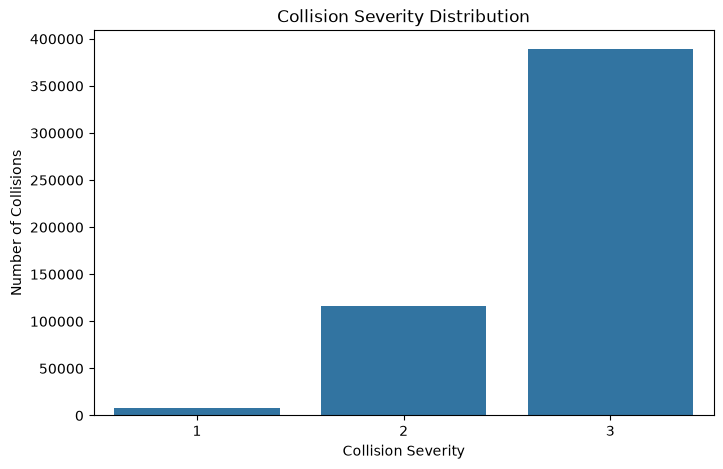

In [24]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=collision_df,
    x="collision_severity"
)

plt.title("Collision Severity Distribution")
plt.xlabel("Collision Severity")
plt.ylabel("Number of Collisions")

plt.show()

## Collision Severity Findings

The `collision_severity` target shows a strong class imbalance.

- **Slight:** 389,435 collisions (75.79%)
- **Serious:** 116,813 collisions (22.74%)
- **Fatal:** 7,553 collisions (1.47%)

Slight collisions represent the majority of observations, while Fatal
collisions represent only a small proportion of the dataset.

This class imbalance is an important consideration for the later
classification stage. Model evaluation should therefore consider
class-specific performance rather than relying only on overall
accuracy.

No class-balancing technique is applied during the EDA stage.

## 12. Number of Casualties Distribution

`number_of_casualties` is the secondary regression target of the
project.

Its distribution is examined to understand the typical casualty count,
overall spread, and presence of extreme observations.

In [25]:
collision_df["number_of_casualties"].describe()

count    513801.000000
mean          1.270572
std           0.726348
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         142.000000
Name: number_of_casualties, dtype: float64

In [26]:
display(
    collision_df["number_of_casualties"]
    .value_counts()
    .sort_index()
)

number_of_casualties
1      418798
2       67034
3       18180
4        6258
5        2303
6         695
7         290
8         110
9          36
10         29
11         15
12         15
13          5
14          7
15          4
16          3
17          3
18          3
19          2
20          3
21          2
22          2
25          1
32          1
70          1
142         1
Name: count, dtype: int64

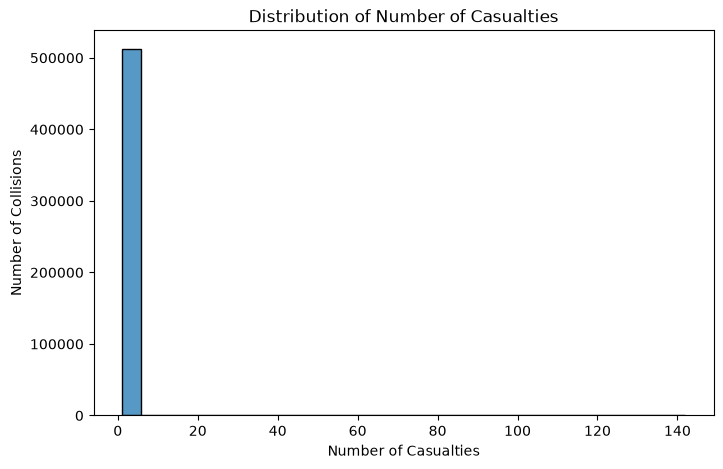

In [27]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=collision_df,
    x="number_of_casualties",
    bins=30
)

plt.title("Distribution of Number of Casualties")
plt.xlabel("Number of Casualties")
plt.ylabel("Number of Collisions")

plt.show()

## Number of Casualties Findings

The `number_of_casualties` variable is strongly right-skewed, with
most collisions involving a small number of casualties.

- **1 casualty:** 418,798 collisions (81.51%)
- **2 casualties:** 67,034 collisions (13.04%)
- **3 casualties:** 18,180 collisions (3.54%)
- Median: **1 casualty**
- Mean: **1.27 casualties**
- Maximum: **142 casualties**

The frequency decreases substantially as the number of casualties
increases. A small number of extreme observations, including
collisions with 70 and 142 casualties, require further investigation.

These extreme values are not automatically considered errors and
should be validated during the later data-quality stage.

## 14. Temporal Distribution of Collisions

The number of collisions is visualised across the available collision
years to examine the temporal distribution of records.

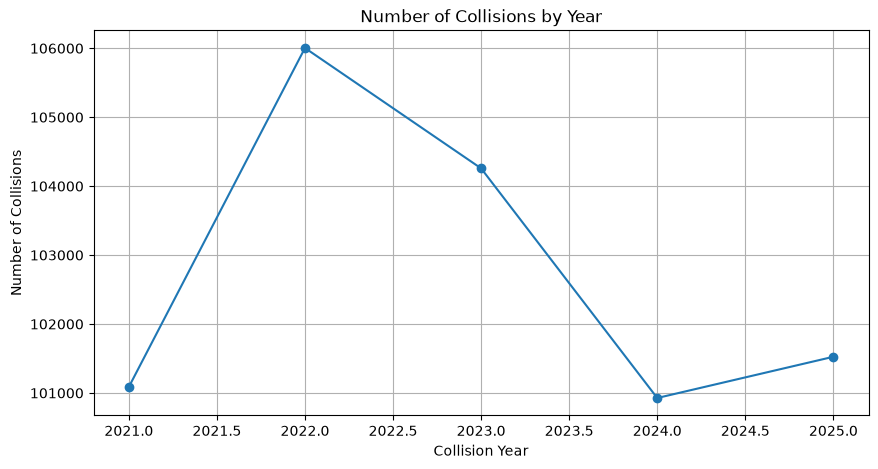

In [28]:
year_counts = (
    collision_df["collision_year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

year_counts.plot(
    kind="line",
    marker="o"
)

plt.title("Number of Collisions by Year")
plt.xlabel("Collision Year")
plt.ylabel("Number of Collisions")

plt.grid(True)
plt.show()

## 15. Collision EDA — Issues Requiring Investigation

The main findings identified during the exploratory analysis are
summarised below.

These observations are recorded for further investigation and do not
represent final data-cleaning decisions.

In [29]:
collision_eda_issues = pd.DataFrame({
    "Issue": [
        "Class imbalance",
        "High coded missing values",
        "High coded missing values",
        "Missing geographic coordinates",
        "Extreme number of vehicles",
        "Extreme number of casualties"
    ],
    "Variable": [
        "collision_severity",
        "junction_control",
        "special_conditions_at_site",
        "latitude / longitude / OSGR coordinates",
        "number_of_vehicles",
        "number_of_casualties"
    ],
    "Observation": [
        "Fatal 1.47%, Serious 22.74%, Slight 75.79%",
        "`-1` occurs in 42.41% of records",
        "`-1` occurs in 29.46% of records",
        "53 missing values in each geographic field",
        "Maximum value is 26 while median is 2",
        "Maximum value is 142 while median is 1"
    ],
    "Requires Investigation": [
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes"
    ]
})

display(collision_eda_issues)

,Issue,Variable,Observation,Requires Investigation
0,Class imbalance,collision_severity,"Fatal 1.47%, Serious 22.74%, Slight 75.79%",Yes
1,High coded missing values,junction_control,`-1` occurs in 42.41% of records,Yes
2,High coded missing values,special_conditions_at_site,`-1` occurs in 29.46% of records,Yes
3,Missing geographic coordinates,latitude / longitude / OSGR coordinates,53 missing values in each geographic field,Yes
4,Extreme number of vehicles,number_of_vehicles,Maximum value is 26 while median is 2,Yes
5,Extreme number of casualties,number_of_casualties,Maximum value is 142 while median is 1,Yes
